# Yq12 evolutionary analysis 
## Questions

1. **Are DYZ1 and DYZ2 evolutionary changes coupled?**  
   Fit one bivariate Brownian model to `log2(DYZ1)` and `log2(DYZ2)`. The primary test is whether the evolutionary covariance is zero.
   
3. **Do DYZ1 and DYZ2 have unequal evolutionary rates?**  
   Compare the full Brownian model with a model requiring equal marginal evolutionary variances. This is the second primary inferential test. The DYZ1/DYZ2 evolutionary-variance ratio is the effect size.

4. **Is the phylogenetic framing justified?**  
   Estimate one joint Pagel's lambda for the two repeat families using the original, unpruned 142-tip tree. 

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from Bio import Phylo
from scipy.optimize import minimize_scalar
from scipy.stats import chi2

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
pd.set_option("display.max_columns", 100)

## 1. Paths and settings

In [2]:
PROJECT_DIR = Path(
    "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY"
)

QC_PATH = PROJECT_DIR / "QC/LocationFiles/Yq12_QC_File.txt"
TREE_PATH = PROJECT_DIR / "Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex"
YQ12_STATS_PATH = PROJECT_DIR / "Data/Yq12/Yq12_GeneralStats_wAlus.csv"
ARCHITECTURE_DIR = PROJECT_DIR / "Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter"

OUTPUT_DIR = Path("Yq12_FINAL_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260826
N_INTERVAL_SIM = 10_000       
N_OU_BOOT = 1_000             
SIM_BATCH_SIZE = 5_000

FOCAL_REPEAT_MAP = {
    "DYZ1_Yq": "DYZ1",
    "DYZ2_Con": "DYZ2",
}

## 2. Load the Yq12-QC sample list and summary table

In [3]:
def normalize_sample_name(name):
    name = str(name).strip().strip("'").strip('"')
    if "_chrY" in name:
        name = name.split("_chrY")[0]
    return name


goodYq12Samples = []
with QC_PATH.open("r") as handle:
    for line in handle:
        sample = normalize_sample_name(line)
        if sample:
            goodYq12Samples.append(sample)

if len(goodYq12Samples) != len(set(goodYq12Samples)):
    raise ValueError("Duplicate sample IDs were found in the Yq12 QC list.")


yq12df = pd.read_csv(YQ12_STATS_PATH).drop(
    columns=["Unnamed: 0.1"], errors="ignore"
)
if "Unnamed: 0" in yq12df.columns:
    yq12df = yq12df.set_index("Unnamed: 0")
elif yq12df.index.name is None or isinstance(yq12df.index, pd.RangeIndex):
    first = yq12df.columns[0]
    yq12df = yq12df.set_index(first)

yq12df.index = [normalize_sample_name(x) for x in yq12df.index]

missing_stats = sorted(set(goodYq12Samples) - set(yq12df.index))
if missing_stats:
    raise ValueError(
        "QC-passing samples missing from the Yq12 summary table:\n" + "\n".join(missing_stats)
    )

print("Yq12 QC-passing samples:", len(goodYq12Samples))
print("Yq12 summary-table rows:", len(yq12df))

Yq12 QC-passing samples: 84
Yq12 summary-table rows: 84


## 3. Load ordered Yq12 architecture annotations

Two tables are retained:

- `architecture_all_rows`: every annotation row, preserving intervening non-DYZ1/DYZ2 annotations;
- `yq12_architecture`: the focal DYZ1/DYZ2 rows used for repeat-family counts.

In [4]:
all_architecture_dfs = []
architecture_file_diagnostics = []

for file_path in sorted(ARCHITECTURE_DIR.iterdir()):
    if not file_path.is_file():
        continue

    sample_id = normalize_sample_name(file_path.name.split(".")[0])
    architecture_file_diagnostics.append({
        "file_name": file_path.name,
        "sample_id": sample_id,
        "in_QC_set": sample_id in goodYq12Samples,
    })

    if sample_id not in goodYq12Samples:
        continue

    df = pd.read_csv(file_path).drop(columns=["Unnamed: 0"], errors="ignore").copy()
    df.columns = [str(c) for c in df.columns]

    required = {"0", "1", "2", "3", "4", "5"}
    if not required.issubset(df.columns):
        warnings.warn(f"{file_path.name} is missing expected columns; skipping.")
        continue

    df = df.rename(columns={
        "0": "contig",
        "1": "repeat_type",
        "2": "orientation",
        "3": "start",
        "4": "end",
        "5": "subunit_count",
    })
    df["source_row"] = np.arange(len(df))
    df["sample_id"] = sample_id
    df["source_file"] = file_path.name

    for col in ["start", "end"]:
        df[col] = pd.to_numeric(df[col], errors="raise")
    df["subunit_count"] = pd.to_numeric(df["subunit_count"], errors="coerce")

    df["repeat_family"] = df["repeat_type"].map(FOCAL_REPEAT_MAP)
    df = df.sort_values(["contig", "start", "end", "source_row"]).reset_index(drop=True)
    all_architecture_dfs.append(df)

architecture_all_rows = (
    pd.concat(all_architecture_dfs, ignore_index=True)
    if all_architecture_dfs else pd.DataFrame()
)
architecture_file_diagnostics = pd.DataFrame(architecture_file_diagnostics)

yq12_architecture = (
    architecture_all_rows[architecture_all_rows["repeat_family"].notna()].copy()
    if len(architecture_all_rows) else pd.DataFrame()
)

loaded = set(yq12_architecture["sample_id"].unique()) if len(yq12_architecture) else set()
missing_architecture = sorted(set(goodYq12Samples) - loaded)

print("Architecture files examined:", len(architecture_file_diagnostics))
print("QC samples represented in focal architecture rows:", len(loaded))
print("Focal DYZ1/DYZ2 rows:", len(yq12_architecture))
if missing_architecture:
    warnings.warn(f"Architecture data missing for {len(missing_architecture)} QC samples: {missing_architecture}")

Architecture files examined: 145
QC samples represented in focal architecture rows: 84
Focal DYZ1/DYZ2 rows: 5116


## 4. Construct the primary trait table

In [5]:
trait_columns = [
    "TotalDYZ1Arrays",
    "TotalDYZ2Arrays",
    "TotalDYZ1Subunits",
    "TotalDYZ2Subunits",
    "TotalDYZ1Length",
    "TotalDYZ2Length",
    "Yq12_Subunit_Ratio",
]

missing_columns = [c for c in trait_columns if c not in yq12df.columns]
if missing_columns:
    raise ValueError(f"Missing required Yq12 columns: {missing_columns}")

traits = yq12df.reindex(goodYq12Samples)[trait_columns].copy()
numeric_columns = trait_columns.copy()
for col in numeric_columns:
    traits[col] = pd.to_numeric(traits[col], errors="raise")

if traits[numeric_columns].isna().any().any():
    raise ValueError("Missing numeric values are present in the trait table.")
if (traits[["TotalDYZ1Subunits", "TotalDYZ2Subunits"]] <= 0).any().any():
    raise ValueError("DYZ1 and DYZ2 subunit counts must be positive for log2 analysis.")

traits["DYZ1_DYZ2_ratio"] = traits["TotalDYZ1Subunits"] / traits["TotalDYZ2Subunits"]
traits["log2_DYZ1"] = np.log2(traits["TotalDYZ1Subunits"])
traits["log2_DYZ2"] = np.log2(traits["TotalDYZ2Subunits"])
traits["log2_DYZ1_DYZ2_ratio"] = traits["log2_DYZ1"] - traits["log2_DYZ2"]
traits["size_axis"] = (traits["log2_DYZ1"] + traits["log2_DYZ2"]) / np.sqrt(2)
traits["imbalance_axis"] = (traits["log2_DYZ1"] - traits["log2_DYZ2"]) / np.sqrt(2)

stored_ratio = pd.to_numeric(traits["Yq12_Subunit_Ratio"], errors="coerce")
ratio_diff = np.nanmax(np.abs(stored_ratio - traits["DYZ1_DYZ2_ratio"]))
print("Maximum absolute difference between stored and recalculated DYZ1/DYZ2 ratio:", ratio_diff)

raw_r = np.corrcoef(traits["log2_DYZ1"], traits["log2_DYZ2"])[0, 1]
raw_summary = pd.Series({
    "n": len(traits),
    "DYZ1_subunits_min": traits["TotalDYZ1Subunits"].min(),
    "DYZ1_subunits_max": traits["TotalDYZ1Subunits"].max(),
    "DYZ2_subunits_min": traits["TotalDYZ2Subunits"].min(),
    "DYZ2_subunits_max": traits["TotalDYZ2Subunits"].max(),
    "DYZ1_DYZ2_ratio_mean": traits["DYZ1_DYZ2_ratio"].mean(),
    "DYZ1_DYZ2_ratio_median": traits["DYZ1_DYZ2_ratio"].median(),
    "DYZ1_DYZ2_ratio_min": traits["DYZ1_DYZ2_ratio"].min(),
    "DYZ1_DYZ2_ratio_max": traits["DYZ1_DYZ2_ratio"].max(),
    "raw_log2_DYZ1_DYZ2_correlation": raw_r,
})
display(raw_summary.to_frame("value"))

Maximum absolute difference between stored and recalculated DYZ1/DYZ2 ratio: 2.220446049250313e-16


,value
n,84.000000
DYZ1_subunits_min,1927.000000
DYZ1_subunits_max,8405.000000
DYZ2_subunits_min,1300.000000
DYZ2_subunits_max,9664.000000
DYZ1_DYZ2_ratio_mean,1.004839
DYZ1_DYZ2_ratio_median,0.974262
DYZ1_DYZ2_ratio_min,0.584635
DYZ1_DYZ2_ratio_max,1.629913
raw_log2_DYZ1_DYZ2_correlation,0.850999


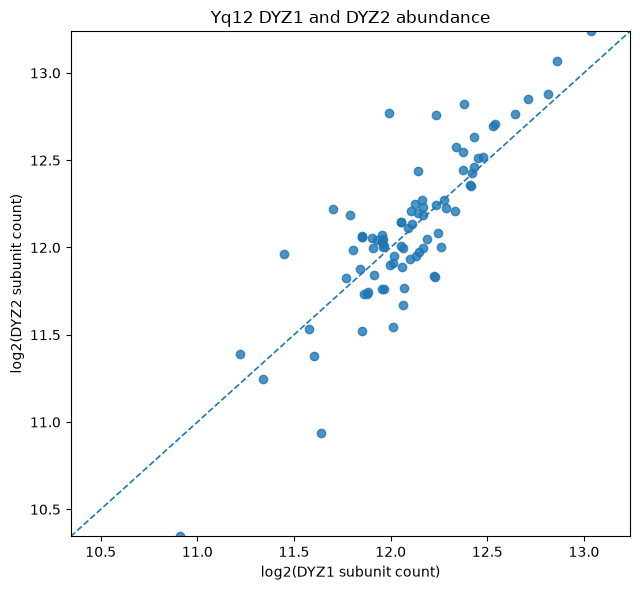

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(traits["log2_DYZ1"], traits["log2_DYZ2"], alpha=0.8)
lims = [
    min(traits["log2_DYZ1"].min(), traits["log2_DYZ2"].min()),
    max(traits["log2_DYZ1"].max(), traits["log2_DYZ2"].max()),
]
ax.plot(lims, lims, linestyle="--", linewidth=1.2)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("log2(DYZ1 subunit count)")
ax.set_ylabel("log2(DYZ2 subunit count)")
ax.set_title("Yq12 DYZ1 and DYZ2 abundance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "DYZ1_DYZ2_log2_scatter.pdf", bbox_inches="tight")
plt.show()

## 5. Structural array QC: explicitly test the ordered sequence

In [7]:
architecture_order_rows = []

if len(architecture_all_rows):
    for (sample_id, contig), grp in architecture_all_rows.groupby(["sample_id", "contig"], sort=False):
        grp = grp.sort_values(["start", "end", "source_row"]).reset_index(drop=True)
        focal_positions = np.flatnonzero(grp["repeat_family"].notna().to_numpy())
        focal = grp.iloc[focal_positions].copy()

        if focal.empty:
            continue

        seq = focal["repeat_family"].tolist()
        alternating_after_filter = all(a != b for a, b in zip(seq[:-1], seq[1:]))
        direct_in_full_annotation = all(
            (b - a == 1) and (seq[i] != seq[i + 1])
            for i, (a, b) in enumerate(zip(focal_positions[:-1], focal_positions[1:]))
        ) if len(seq) > 1 else True
        intervening_nonfocal = int(sum(max(0, b - a - 1) for a, b in zip(focal_positions[:-1], focal_positions[1:])))

        architecture_order_rows.append({
            "sample_id": sample_id,
            "contig": contig,
            "n_focal_arrays": len(seq),
            "n_DYZ1_arrays": seq.count("DYZ1"),
            "n_DYZ2_arrays": seq.count("DYZ2"),
            "equal_DYZ1_DYZ2_counts": seq.count("DYZ1") == seq.count("DYZ2"),
            "focal_sequence_alternates": alternating_after_filter,
            "focal_arrays_directly_adjacent_and_alternate": direct_in_full_annotation,
            "n_intervening_nonfocal_rows": intervening_nonfocal,
            "first_focal_family": seq[0],
            "last_focal_family": seq[-1],
            "opposite_boundary_families": seq[0] != seq[-1],
            "focal_sequence": "-".join(seq),
        })

architecture_order_qc = pd.DataFrame(architecture_order_rows)

if len(yq12_architecture):
    architecture_counts = (
        yq12_architecture.groupby(["sample_id", "repeat_family"])
        .size().unstack(fill_value=0)
    )
    for fam in ["DYZ1", "DYZ2"]:
        if fam not in architecture_counts.columns:
            architecture_counts[fam] = 0

    count_check = traits[["TotalDYZ1Arrays", "TotalDYZ2Arrays"]].join(
        architecture_counts.rename(columns={"DYZ1": "arch_DYZ1", "DYZ2": "arch_DYZ2"}),
        how="left",
    )
    mismatch = count_check[
        (count_check["TotalDYZ1Arrays"] != count_check["arch_DYZ1"])
        | (count_check["TotalDYZ2Arrays"] != count_check["arch_DYZ2"])
    ]
    if len(mismatch):
        warnings.warn(f"Architecture rows do not reproduce summary-table array counts for {len(mismatch)} samples.")
        display(mismatch)
    else:
        print("Architecture rows reproduce summary-table DYZ1/DYZ2 array counts for all QC samples.")

    sample_equal_counts = (traits["TotalDYZ1Arrays"] == traits["TotalDYZ2Arrays"])
    sample_array_summary = pd.Series({
        "n_samples": len(traits),
        "n_samples_equal_DYZ1_DYZ2_array_counts": int(sample_equal_counts.sum()),
        "fraction_samples_equal_DYZ1_DYZ2_array_counts": float(sample_equal_counts.mean()),
        "minimum_DYZ1_arrays": traits["TotalDYZ1Arrays"].min(),
        "maximum_DYZ1_arrays": traits["TotalDYZ1Arrays"].max(),
        "minimum_DYZ2_arrays": traits["TotalDYZ2Arrays"].min(),
        "maximum_DYZ2_arrays": traits["TotalDYZ2Arrays"].max(),
    })
else:
    sample_array_summary = pd.Series(dtype=float)

if len(architecture_order_qc):
    architecture_structural_summary = pd.Series({
        "n_sample_contigs_with_focal_arrays": len(architecture_order_qc),
        "n_focal_sequences_alternating": int(architecture_order_qc["focal_sequence_alternates"].sum()),
        "n_directly_adjacent_and_alternating": int(architecture_order_qc["focal_arrays_directly_adjacent_and_alternate"].sum()),
        "n_with_intervening_nonfocal_rows": int((architecture_order_qc["n_intervening_nonfocal_rows"] > 0).sum()),
        "n_equal_DYZ1_DYZ2_counts_by_contig": int(architecture_order_qc["equal_DYZ1_DYZ2_counts"].sum()),
        "n_opposite_boundary_families_by_contig": int(architecture_order_qc["opposite_boundary_families"].sum()),
    })
    display(sample_array_summary.to_frame("value"))
    display(architecture_structural_summary.to_frame("value"))
    display(architecture_order_qc.head(20))
else:
    architecture_structural_summary = pd.Series(dtype=float)
    warnings.warn("No architecture order table could be constructed.")

Architecture rows reproduce summary-table DYZ1/DYZ2 array counts for all QC samples.


,value
n_samples,84.0
n_samples_equal_DYZ1_DYZ2_array_counts,84.0
fraction_samples_equal_DYZ1_DYZ2_array_counts,1.0
minimum_DYZ1_arrays,13.0
maximum_DYZ1_arrays,68.0
minimum_DYZ2_arrays,13.0
maximum_DYZ2_arrays,68.0


,value
n_sample_contigs_with_focal_arrays,84
n_focal_sequences_alternating,84
n_directly_adjacent_and_alternating,84
n_with_intervening_nonfocal_rows,0
n_equal_DYZ1_DYZ2_counts_by_contig,84
n_opposite_boundary_families_by_contig,84


,sample_id,contig,n_focal_arrays,n_DYZ1_arrays,n_DYZ2_arrays,equal_DYZ1_DYZ2_counts,focal_sequence_alternates,focal_arrays_directly_adjacent_and_alternate,n_intervening_nonfocal_rows,first_focal_family,last_focal_family,opposite_boundary_families,focal_sequence
0,200080,200080_chrY,54,27,27,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
1,200084,200084_chrY,54,27,27,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
2,HG00126,HG00126_chrY,50,25,25,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
3,HG002,HG002_chrY,86,43,43,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
4,HG00280,HG00280_chrY,74,37,37,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
5,HG00290,HG00290_chrY,78,39,39,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
6,HG00358,HG00358_chrY,78,39,39,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
7,HG00512,HG00512_chrY,136,68,68,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
8,HG00609,HG00609_chrY,102,51,51,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...
9,HG00621,HG00621_chrY,60,30,30,True,True,True,0,DYZ1,DYZ2,True,DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-DYZ2-DYZ1-D...


## 6. Build the phylogenetic covariance matrix from the original full tree

The 84 analysis samples are selected from the original 142-tip rooted tree without pruning the tree first. This preserves the original root-to-tip and root-to-MRCA distances.

`C[i,j]` is root-to-MRCA branch length and `C[i,i]` is root-to-tip branch length.

In [8]:
def phylogenetic_covariance_matrix(tree, tip_order):
    terminals = {tip.name: tip for tip in tree.get_terminals()}
    missing = [name for name in tip_order if name not in terminals]
    if missing:
        raise ValueError(f"Tips missing from tree: {missing}")

    n = len(tip_order)
    C = np.zeros((n, n), dtype=float)
    root_distance = {
        name: tree.distance(tree.root, terminals[name])
        for name in tip_order
    }

    for i, name_i in enumerate(tip_order):
        C[i, i] = root_distance[name_i]
        for j in range(i):
            name_j = tip_order[j]
            mrca = tree.common_ancestor(terminals[name_i], terminals[name_j])
            C[i, j] = C[j, i] = tree.distance(tree.root, mrca)
    return C


tree_all = Phylo.read(TREE_PATH, "nexus")
for tip in tree_all.get_terminals():
    tip.name = normalize_sample_name(tip.name)

tree_tip_names = [tip.name for tip in tree_all.get_terminals()]
if len(tree_tip_names) != len(set(tree_tip_names)):
    raise ValueError("Tree-tip names are not unique after normalization.")

missing_tree = sorted(set(goodYq12Samples) - set(tree_tip_names))
if missing_tree:
    raise ValueError("QC samples missing from the phylogeny:\n" + "\n".join(missing_tree))

if not tree_all.rooted:
    warnings.warn("The NEXUS tree is not flagged as rooted. Confirm that the encoded root is intended.")

nonroot = [c for c in tree_all.find_clades(order="preorder") if c is not tree_all.root]
if any(c.branch_length is None for c in nonroot):
    raise ValueError("Some branches have no branch length.")
if any(c.branch_length < 0 for c in nonroot):
    raise ValueError("Negative branch lengths are present.")

tip_order = traits.index.tolist()
C = phylogenetic_covariance_matrix(tree_all, tip_order)

min_eig = float(np.linalg.eigvalsh(C).min())
if min_eig <= 1e-12:
    raise ValueError(
        f"Full-tree covariance matrix is not sufficiently positive definite (min eigenvalue={min_eig:.3e})."
    )

C_chol = np.linalg.cholesky(C)
root_depths = np.diag(C)
root_depth_summary = pd.Series({
    "n_full_tree_tips": len(tree_all.get_terminals()),
    "n_analysis_tips": len(tip_order),
    "root_to_tip_mean": root_depths.mean(),
    "root_to_tip_sd": root_depths.std(ddof=1),
    "root_to_tip_CV_percent": 100 * root_depths.std(ddof=1) / root_depths.mean(),
    "root_to_tip_min": root_depths.min(),
    "root_to_tip_max": root_depths.max(),
    "minimum_covariance_eigenvalue": min_eig,
})
display(root_depth_summary.to_frame("value"))

,value
n_full_tree_tips,1.420000e+02
n_analysis_tips,8.400000e+01
root_to_tip_mean,1.842927e-01
root_to_tip_sd,7.990061e-07
root_to_tip_CV_percent,4.335529e-04
root_to_tip_min,1.842910e-01
root_to_tip_max,1.842940e-01
minimum_covariance_eigenvalue,2.700000e-05


## 7. Statistical functions

The bivariate Brownian fit estimates one 2 x 2 evolutionary rate matrix. That matrix contains the two main biological results:

- the off-diagonal covariance/correlation = Finding A: coupling
- the unequal diagonal variances = Finding B: rate asymmetry

In [9]:
def prepare_phylo_whitening(C):
    L = np.linalg.cholesky(C)
    ones = np.ones(C.shape[0], dtype=float)
    ones_w = np.linalg.solve(L, ones)
    return {
        "L": L,
        "ones_w": ones_w,
        "denom": float(ones_w @ ones_w),
    }


def fit_bivariate_bm(Y, C):
    Y = np.asarray(Y, dtype=float)
    n, p = Y.shape
    if p != 2:
        raise ValueError("Y must have exactly two columns.")

    W = prepare_phylo_whitening(C)
    Yw = np.linalg.solve(W["L"], Y)
    mu = (W["ones_w"] @ Yw) / W["denom"]
    E = Yw - np.outer(W["ones_w"], mu)
    SSE = E.T @ E
    Sigma = SSE / n

    s11, s22, s12 = float(Sigma[0,0]), float(Sigma[1,1]), float(Sigma[0,1])
    rho = s12 / np.sqrt(s11 * s22)
    var_S = (s11 + s22 + 2*s12) / 2
    var_I = (s11 + s22 - 2*s12) / 2

    rho_clip = np.clip(rho, -1 + 1e-15, 1 - 1e-15)
    lrt_coupling = -n * np.log1p(-(rho_clip ** 2))

    v = (s11 + s22) / 2
    Sigma_equal = np.array([[v, s12], [s12, v]], dtype=float)
    det_full = np.linalg.det(Sigma)
    det_equal = np.linalg.det(Sigma_equal)
    if det_full <= 0 or det_equal <= 0:
        raise ValueError("Fitted covariance matrices are not positive definite.")
    lrt_equal_variance = n * np.log(det_equal / det_full)

    return {
        "n": n,
        "mu": mu,
        "Sigma": Sigma,
        "rho": rho,
        "var_S": var_S,
        "var_I": var_I,
        "S_over_I": var_S / var_I,
        "I_over_S": var_I / var_S,
        "variance_ratio_DYZ1_DYZ2": s11 / s22,
        "Sigma_equal_variance": Sigma_equal,
        "LRT_coupling": lrt_coupling,
        "P_coupling": chi2.sf(lrt_coupling, 1),
        "LRT_equal_variance": lrt_equal_variance,
        "P_equal_variance": chi2.sf(lrt_equal_variance, 1),
        "derived_beta_R_on_S": ((s11 - s22) / np.sqrt(2)) / var_S,
        "derived_beta_R_on_S_if_independent": ((s11 - s22) / np.sqrt(2)) / ((s11 + s22) / 2),
    }


def simulate_fitted_covariance_statistics(Sigma, n_tips, n_sim, seed, batch_size=5_000):
    """Parametric sampling distribution of the fitted 2x2 BM rate matrix.

    With one fitted intercept, the whitened residual SSCP has df=n_tips-1 and the ML
    covariance estimator uses divisor n_tips.
    """
    rng = np.random.default_rng(seed)
    chol = np.linalg.cholesky(np.asarray(Sigma, float))
    df = n_tips - 1

    out = {
        "rho": np.empty(n_sim),
        "S_over_I": np.empty(n_sim),
        "var_ratio_DYZ1_DYZ2": np.empty(n_sim),
    }

    start = 0
    while start < n_sim:
        stop = min(start + batch_size, n_sim)
        b = stop - start
        X = rng.standard_normal((b, df, 2)) @ chol.T
        x1, x2 = X[:,:,0], X[:,:,1]
        s11 = np.sum(x1*x1, axis=1) / n_tips
        s22 = np.sum(x2*x2, axis=1) / n_tips
        s12 = np.sum(x1*x2, axis=1) / n_tips
        var_S = (s11 + s22 + 2*s12) / 2
        var_I = (s11 + s22 - 2*s12) / 2
        out["rho"][start:stop] = s12 / np.sqrt(s11*s22)
        out["S_over_I"][start:stop] = var_S / var_I
        out["var_ratio_DYZ1_DYZ2"][start:stop] = s11 / s22
        start = stop
    return out


def joint_bm_loglik(Y, C):
    """Profile matrix-normal BM log-likelihood with a free mean per trait and free 2x2 Sigma."""
    Y = np.asarray(Y, float)
    n, p = Y.shape
    L = np.linalg.cholesky(C)
    logdetC = 2 * np.sum(np.log(np.diag(L)))
    Yw = np.linalg.solve(L, Y)
    ow = np.linalg.solve(L, np.ones(n))
    mu = (ow @ Yw) / (ow @ ow)
    E = Yw - np.outer(ow, mu)
    Sigma = (E.T @ E) / n
    sign, logdetS = np.linalg.slogdet(Sigma)
    if sign <= 0:
        return -np.inf, mu, Sigma
    ll = -0.5 * (n*p*np.log(2*np.pi) + p*logdetC + n*logdetS + n*p)
    return float(ll), mu, Sigma


def lambda_transform(C, lam):
    """Pagel lambda: scale shared phylogenetic covariance, leaving tip variances fixed."""
    return lam * C + (1 - lam) * np.diag(np.diag(C))


def fit_joint_pagel_lambda(Y, C):
    """One Pagel-lambda model for the joint DYZ1/DYZ2 trait matrix."""
    f = lambda lam: -joint_bm_loglik(Y, lambda_transform(C, lam))[0]
    opt = minimize_scalar(f, bounds=(0.0, 1.0), method="bounded", options={"xatol": 1e-6})
    lam = float(opt.x)
    ll_lam = -float(opt.fun)
    ll_bm = joint_bm_loglik(Y, C)[0]
    ll_ind = joint_bm_loglik(Y, lambda_transform(C, 0.0))[0]

    return {
        "lambda": lam,
        "loglik_lambda": ll_lam,
        "loglik_BM": ll_bm,
        "loglik_no_shared_phylogeny": ll_ind,
        "AIC_lambda": -2*ll_lam + 2*6,
        "AIC_BM": -2*ll_bm + 2*5,
        "AIC_no_shared_phylogeny": -2*ll_ind + 2*5,
    }


def _gls_profile_loglik(y, V):
    """Profile log-likelihood of y ~ N(mu*1, sigma2*V)."""
    y = np.asarray(y, float)
    n = len(y)
    L = np.linalg.cholesky(V)
    logdetV = 2 * np.sum(np.log(np.diag(L)))
    yw = np.linalg.solve(L, y)
    ow = np.linalg.solve(L, np.ones(n))
    mu = (ow @ yw) / (ow @ ow)
    r = yw - ow * mu
    s2 = (r @ r) / n
    ll = -0.5 * (n*np.log(2*np.pi) + logdetV + n*np.log(s2) + n)
    return float(ll), float(mu), float(s2)


def ou_covariance(C, alpha):
    """Single-optimum OU covariance with the root fixed at the optimum; tends to C as alpha->0."""
    d = np.diag(C)
    sep = d[:, None] + d[None, :] - 2*C
    if alpha <= 0:
        return C.copy()
    return np.exp(-alpha * sep) * (-np.expm1(-2*alpha*C)) / (2*alpha)


def fit_ou_vs_bm(y, C):
    """Fit BM and a root-at-optimum OU model for one trait."""
    y = np.asarray(y, float)
    mean_depth = float(np.mean(np.diag(C)))
    log_bounds = (
        np.log(1e-4 / mean_depth),
        np.log(1e4 / mean_depth),
    )
    objective = lambda loga: -_gls_profile_loglik(y, ou_covariance(C, np.exp(loga)))[0]
    opt = minimize_scalar(objective, bounds=log_bounds, method="bounded", options={"xatol": 1e-6})
    alpha = float(np.exp(opt.x))
    ll_ou = -float(opt.fun)
    ll_bm, mu_bm, s2_bm = _gls_profile_loglik(y, C)
    T = max(0.0, 2*(ll_ou - ll_bm))
    return {
        "alpha": alpha,
        "alpha_times_mean_depth": alpha * mean_depth,
        "half_life": np.log(2) / alpha,
        "half_life_over_mean_depth": (np.log(2) / alpha) / mean_depth,
        "loglik_OU": ll_ou,
        "loglik_BM": ll_bm,
        "T": T,
        "delta_AIC_OU_minus_BM": (-2*ll_ou + 2*3) - (-2*ll_bm + 2*2),
        "BM_mu": mu_bm,
        "BM_sigma2": s2_bm,
        "alpha_at_search_boundary": bool(
            abs(opt.x - log_bounds[0]) < 1e-3 or abs(opt.x - log_bounds[1]) < 1e-3
        ),
    }


def empirical_ou_pvalue(y, C, n_sim, seed):
    """Parametric-bootstrap P value for OU vs BM, simulating under the fitted BM null."""
    observed = fit_ou_vs_bm(y, C)
    rng = np.random.default_rng(seed)
    L = np.linalg.cholesky(C)
    n = len(y)
    exceed = 0
    T_sim = np.empty(n_sim)

    for i in range(n_sim):
        sim = observed["BM_mu"] + np.sqrt(observed["BM_sigma2"]) * (L @ rng.standard_normal(n))
        fit = fit_ou_vs_bm(sim, C)
        T_sim[i] = fit["T"]
        exceed += fit["T"] >= observed["T"] - 1e-12

    p = (exceed + 1) / (n_sim + 1)
    return observed, p, T_sim

## 8. Model adequacy: one joint Pagel's lambda

This asks whether the DYZ1/DYZ2 trait pair retains shared covariance along the SNP-based Y phylogeny. `lambda = 1` is the original Brownian covariance; `lambda = 0` removes shared phylogenetic covariance while retaining each tip's diagonal variance.

This section is a model check, not an additional biological finding.

In [10]:
Y_subunits = traits[["log2_DYZ1", "log2_DYZ2"]].to_numpy()
lambda_fit = fit_joint_pagel_lambda(Y_subunits, C)

lambda_summary = pd.Series({
    "joint_Pagel_lambda": lambda_fit["lambda"],
    "AIC_fitted_lambda": lambda_fit["AIC_lambda"],
    "AIC_BM_lambda_1": lambda_fit["AIC_BM"],
    "AIC_no_shared_phylogeny_lambda_0": lambda_fit["AIC_no_shared_phylogeny"],
    "delta_AIC_lambda_minus_BM": lambda_fit["AIC_lambda"] - lambda_fit["AIC_BM"],
    "delta_AIC_lambda_minus_no_shared_phylogeny": lambda_fit["AIC_lambda"] - lambda_fit["AIC_no_shared_phylogeny"],
})
display(lambda_summary.to_frame("value"))

if lambda_fit["lambda"] < 0.2:
    warnings.warn(
        "Joint Pagel lambda is very low. Treat phylogenetic/evolutionary wording cautiously; "
        "the data may be close to independent tips at this phylogenetic depth."
    )

,value
joint_Pagel_lambda,0.999999
AIC_fitted_lambda,-29.526668
AIC_BM_lambda_1,-31.537627
AIC_no_shared_phylogeny_lambda_0,59.414125
delta_AIC_lambda_minus_BM,2.010960
delta_AIC_lambda_minus_no_shared_phylogeny,-88.940793


## 9. Primary Brownian results

In [11]:
bm_fit = fit_bivariate_bm(Y_subunits, C)
s11 = float(bm_fit["Sigma"][0,0])
s22 = float(bm_fit["Sigma"][1,1])
s12 = float(bm_fit["Sigma"][0,1])

bm_summary = pd.Series({
    "n_tips": bm_fit["n"],
    "evolutionary_variance_DYZ1": s11,
    "evolutionary_variance_DYZ2": s22,
    "evolutionary_covariance_DYZ1_DYZ2": s12,
    "evolutionary_correlation_rho": bm_fit["rho"],
    "shared_axis_variance_S": bm_fit["var_S"],
    "imbalance_axis_variance_I": bm_fit["var_I"],
    "shared_to_imbalance_variance_ratio": bm_fit["S_over_I"],
    "DYZ1_to_DYZ2_evolutionary_variance_ratio": bm_fit["variance_ratio_DYZ1_DYZ2"],
    "Finding_A_LRT": bm_fit["LRT_coupling"],
    "Finding_A_P_coupling": bm_fit["P_coupling"],
    "Finding_B_LRT": bm_fit["LRT_equal_variance"],
    "Finding_B_P_equal_variance": bm_fit["P_equal_variance"],
    "derived_beta_log2_DYZ1_DYZ2_on_S": bm_fit["derived_beta_R_on_S"],
    "derived_beta_if_DYZ1_DYZ2_independent": bm_fit["derived_beta_R_on_S_if_independent"],
})
display(bm_summary.to_frame("value"))

print("FINDING A — coupling")
print(f"  evolutionary rho = {bm_fit['rho']:.6f}")
print(f"  S/I variance ratio = {bm_fit['S_over_I']:.3f}  [effect-size re-expression]")
print(f"  LRT P = {bm_fit['P_coupling']:.6g}")

print("\nFINDING B — rate asymmetry")
vr = bm_fit["variance_ratio_DYZ1_DYZ2"]
more_variable = "DYZ2" if vr < 1 else "DYZ1"
fold = 1/vr if vr < 1 else vr
print(f"  DYZ1/DYZ2 evolutionary-variance ratio = {vr:.6f}")
print(f"  {more_variable} has {fold:.3f}-fold greater evolutionary variance")
print(f"  LRT P = {bm_fit['P_equal_variance']:.6g}")

print("\nDerived composition-size consequence — NOT a third test")
print(f"  beta[log2(DYZ1/DYZ2) ~ S] implied by fitted Sigma = {bm_fit['derived_beta_R_on_S']:+.6f}")
print(f"  same beta if covariance were zero = {bm_fit['derived_beta_R_on_S_if_independent']:+.6f}")
if abs(bm_fit["derived_beta_R_on_S"]) < abs(bm_fit["derived_beta_R_on_S_if_independent"]):
    print("  => positive DYZ1-DYZ2 coupling attenuates the compositional trend produced by unequal rates.")

,value
n_tips,8.400000e+01
evolutionary_variance_DYZ1,4.135564e+00
evolutionary_variance_DYZ2,7.509718e+00
evolutionary_covariance_DYZ1_DYZ2,5.076786e+00
evolutionary_correlation_rho,9.109817e-01
shared_axis_variance_S,1.089943e+01
imbalance_axis_variance_I,7.458549e-01
shared_to_imbalance_variance_ratio,1.461333e+01
DYZ1_to_DYZ2_evolutionary_variance_ratio,5.506950e-01
Finding_A_LRT,1.487889e+02


FINDING A — coupling
  evolutionary rho = 0.910982
  S/I variance ratio = 14.613  [effect-size re-expression]
  LRT P = 3.18918e-34

FINDING B — rate asymmetry
  DYZ1/DYZ2 evolutionary-variance ratio = 0.550695
  DYZ2 has 1.816-fold greater evolutionary variance
  LRT P = 1.78004e-09

Derived composition-size consequence — NOT a third test
  beta[log2(DYZ1/DYZ2) ~ S] implied by fitted Sigma = -0.218900
  same beta if covariance were zero = -0.409760
  => positive DYZ1-DYZ2 coupling attenuates the compositional trend produced by unequal rates.


## 10. Simulation-based 95% intervals under the fitted Brownian model

These are parametric simulation intervals around the fitted model.

In [12]:
interval_sim = simulate_fitted_covariance_statistics(
    bm_fit["Sigma"],
    n_tips=bm_fit["n"],
    n_sim=N_INTERVAL_SIM,
    seed=RANDOM_SEED + 1,
    batch_size=SIM_BATCH_SIZE,
)

q = lambda x, p: float(np.quantile(x, p))
interval_summary = pd.Series({
    "N_simulations": N_INTERVAL_SIM,
    "rho_observed": bm_fit["rho"],
    "rho_2.5": q(interval_sim["rho"], 0.025),
    "rho_97.5": q(interval_sim["rho"], 0.975),
    "S_over_I_observed": bm_fit["S_over_I"],
    "S_over_I_2.5": q(interval_sim["S_over_I"], 0.025),
    "S_over_I_97.5": q(interval_sim["S_over_I"], 0.975),
    "DYZ1_DYZ2_variance_ratio_observed": bm_fit["variance_ratio_DYZ1_DYZ2"],
    "DYZ1_DYZ2_variance_ratio_2.5": q(interval_sim["var_ratio_DYZ1_DYZ2"], 0.025),
    "DYZ1_DYZ2_variance_ratio_97.5": q(interval_sim["var_ratio_DYZ1_DYZ2"], 0.975),
})
display(interval_summary.to_frame("value"))

,value
N_simulations,10000.000000
rho_observed,0.910982
rho_2.5,0.868523
rho_97.5,0.941727
S_over_I_observed,14.613335
S_over_I_2.5,10.335084
S_over_I_97.5,20.653302
DYZ1_DYZ2_variance_ratio_observed,0.550695
DYZ1_DYZ2_variance_ratio_2.5,0.459416
DYZ1_DYZ2_variance_ratio_97.5,0.658452


In [15]:
bp_per_subunit = pd.DataFrame({
    "DYZ1": traits["TotalDYZ1Length"] / traits["TotalDYZ1Subunits"],
    "DYZ2": traits["TotalDYZ2Length"] / traits["TotalDYZ2Subunits"],
})
unit_check = pd.DataFrame({
    "mean_bp_per_subunit": bp_per_subunit.mean(),
    "sd_bp_per_subunit": bp_per_subunit.std(ddof=1),
    "CV_percent": 100 * bp_per_subunit.std(ddof=1) / bp_per_subunit.mean(),
    "min_bp_per_subunit": bp_per_subunit.min(),
    "max_bp_per_subunit": bp_per_subunit.max(),
})
display(unit_check)

,mean_bp_per_subunit,sd_bp_per_subunit,CV_percent,min_bp_per_subunit,max_bp_per_subunit
DYZ1,3478.320501,10.830942,0.311384,3441.287432,3509.389203
DYZ2,2405.907908,3.241226,0.134719,2397.745882,2417.656410
